# Remove Extreme Pupil Size Outliers

For each subject, remove extreme outliers where left and right pupil sizes are in total disagreement (e.g., one is more than 2x the other).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns

## Load Dataset

In [20]:
data_dir = "../../data/processed/eSEEd_v2_processed/"

def load_eseed_dataset(data_dir):
    start_time = time.time()
    df = pd.DataFrame()
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df_part = pd.read_csv(os.path.join(data_dir, csv_file))
            df = pd.concat([df, df_part], ignore_index=True)
    print(f"Loaded eSEEd dataset in {time.time() - start_time:.2f} seconds.")
    return df

df = load_eseed_dataset(data_dir)
print(f"Total rows: {len(df):,}")
print(f"Subjects: {df['subject'].nunique()}")
print(f"Recordings: {df['recording'].nunique()}")

Loaded eSEEd dataset in 11.34 seconds.
Total rows: 3,423,045
Subjects: 48
Recordings: 10


## Define Outlier Removal Function

Remove points where:
- One pupil is more than 2x the other
- Either pupil is missing (NaN)

In [28]:
def remove_pupil_outliers(df, ratio_threshold=2.0):
    """
    Remove extreme pupil size outliers where left/right disagreement is extreme.
    
    Args:
        df: DataFrame with pupil-size-left-avg and pupil-size-right-avg columns
        ratio_threshold: Remove points where max(left/right, right/left) > ratio_threshold
    
    Returns:
        df_clean: Cleaned DataFrame
        stats: Dictionary with removal statistics per subject
    """
    df_clean = df.copy()
    
    # Get pupil columns
    left = df_clean['pupil-size-left-avg'].values
    right = df_clean['pupil-size-right-avg'].values
    
    # Find valid points (both pupils present and > 0.1mm)
    min_valid_size = 0.1
    valid_mask = (left > min_valid_size) & (right > min_valid_size) & (~np.isnan(left)) & (~np.isnan(right))
    
    # Compute ratio for all valid points: max(left/right, right/left)
    ratio = np.ones(len(df_clean)) * np.nan
    ratio[valid_mask] = np.maximum(
        left[valid_mask] / right[valid_mask],
        right[valid_mask] / left[valid_mask]
    )
    
    # Identify outliers globally
    outlier_global_mask = ratio > ratio_threshold
    
    # Remove outliers by setting to NaN
    df_clean.loc[outlier_global_mask, 'pupil-size-left-avg'] = np.nan
    df_clean.loc[outlier_global_mask, 'pupil-size-right-avg'] = np.nan
    
    # Compute statistics per subject
    stats = []
    for subject in df['subject'].unique():
        subject_mask = df['subject'] == subject
        
        # Count for this subject
        initial_valid = valid_mask[subject_mask].sum()
        outliers_in_subject = outlier_global_mask[subject_mask].sum()
        
        if initial_valid > 0:
            pct_removed = (outliers_in_subject / initial_valid) * 100
        else:
            pct_removed = 0
        
        stats.append({
            'subject': subject,
            'initial_valid': int(initial_valid),
            'outliers_removed': int(outliers_in_subject),
            'pct_removed': pct_removed,
            'remaining_valid': int(initial_valid - outliers_in_subject)
        })
    
    df_stats = pd.DataFrame(stats).sort_values('pct_removed', ascending=False)
    
    return df_clean, df_stats

## Apply Outlier Removal

In [29]:
ratio_threshold = 2.0  # Remove if one pupil > 2x the other

df_cleaned, removal_stats = remove_pupil_outliers(df, ratio_threshold=ratio_threshold)

print(f"\nOutlier Removal Statistics (ratio threshold = {ratio_threshold}):")
print("=" * 80)
print(removal_stats.to_string(index=False))

print(f"\n\nSummary:")
print(f"  Total outliers removed: {removal_stats['outliers_removed'].sum():,}")
print(f"  Median % removed per subject: {removal_stats['pct_removed'].median():.2f}%")
print(f"  Max % removed (single subject): {removal_stats['pct_removed'].max():.2f}%")
print(f"  Subjects with >1% removed: {(removal_stats['pct_removed'] > 1).sum()}")
print(f"  Subjects with >5% removed: {(removal_stats['pct_removed'] > 5).sum()}")


Outlier Removal Statistics (ratio threshold = 2.0):
 subject  initial_valid  outliers_removed  pct_removed  remaining_valid
       8          70762             12301    17.383624            58461
      13          69893              4953     7.086547            64940
      36          72215              4180     5.788271            68035
      15          59853              2767     4.622993            57086
       6          69511              2437     3.505920            67074
      16          69514              2107     3.031044            67407
      39          69606              1514     2.175100            68092
      31          69966              1428     2.040991            68538
      37          70771               830     1.172797            69941
       3          54577               480     0.879491            54097
      46          71414               552     0.772958            70862
      43          72554               380     0.523748            72174
      44   

## Compute Statistics for Comparison

In [30]:
def compute_pupil_stats(df, label=""):
    """Compute pupil size comparison statistics per subject."""
    df_pupils = df[['subject', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    
    stats_per_subject = []
    for subject in df_pupils['subject'].unique():
        left = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-left-avg']
        right = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-right-avg']
        
        stats_per_subject.append({
            'subject': subject,
            'n_samples': len(left),
            'corr': left.corr(right),
            'mae': np.abs(left - right).mean(),
            'rmse': np.sqrt(((left - right) ** 2).mean()),
            'max_diff': np.abs(left - right).max(),
            'mean_left': left.mean(),
            'mean_right': right.mean()
        })
    
    return pd.DataFrame(stats_per_subject).sort_values('mae', ascending=False)

# Compute stats for original and cleaned data
stats_original = compute_pupil_stats(df, "original")
stats_cleaned = compute_pupil_stats(df_cleaned, "cleaned")

print("\n" + "="*80)
print("BEFORE CLEANING - Top 10 subjects by MAE:")
print("="*80)
print(stats_original.head(10).to_string(index=False))

print("\n" + "="*80)
print("AFTER CLEANING - Top 10 subjects by MAE:")
print("="*80)
print(stats_cleaned.head(10).to_string(index=False))


BEFORE CLEANING - Top 10 subjects by MAE:
 subject  n_samples      corr      mae     rmse  max_diff  mean_left  mean_right
      13      72294  0.151514 2.398021 7.856497 74.937087   4.942705    5.638466
      36      72304  0.330713 1.878270 2.213668 10.760143   3.878155    5.696354
       8      70844 -0.050319 1.368475 2.126451 16.791636   3.726843    5.007116
       5      70358  0.288376 1.118932 1.248991  3.149660   4.235186    5.127849
      39      72118  0.045065 0.932488 3.209690 27.407175   4.045557    4.445536
      15      59990 -0.188267 0.889130 2.074470 49.321370   3.207748    2.624827
       6      69520 -0.010189 0.871335 3.737406 40.488822   2.723243    3.053700
      31      71154 -0.005105 0.754558 2.271158 34.349830   3.692043    3.343433
      37      72169  0.056636 0.710343 1.672432 56.875803   4.217379    3.895883
      40      70206  0.541422 0.675755 0.822676  3.950959   4.153895    3.496902

AFTER CLEANING - Top 10 subjects by MAE:
 subject  n_samples     

## Visualize: Scatter Plots Before vs After Cleaning

Show the 6 most problematic subjects (highest MAE in original data)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

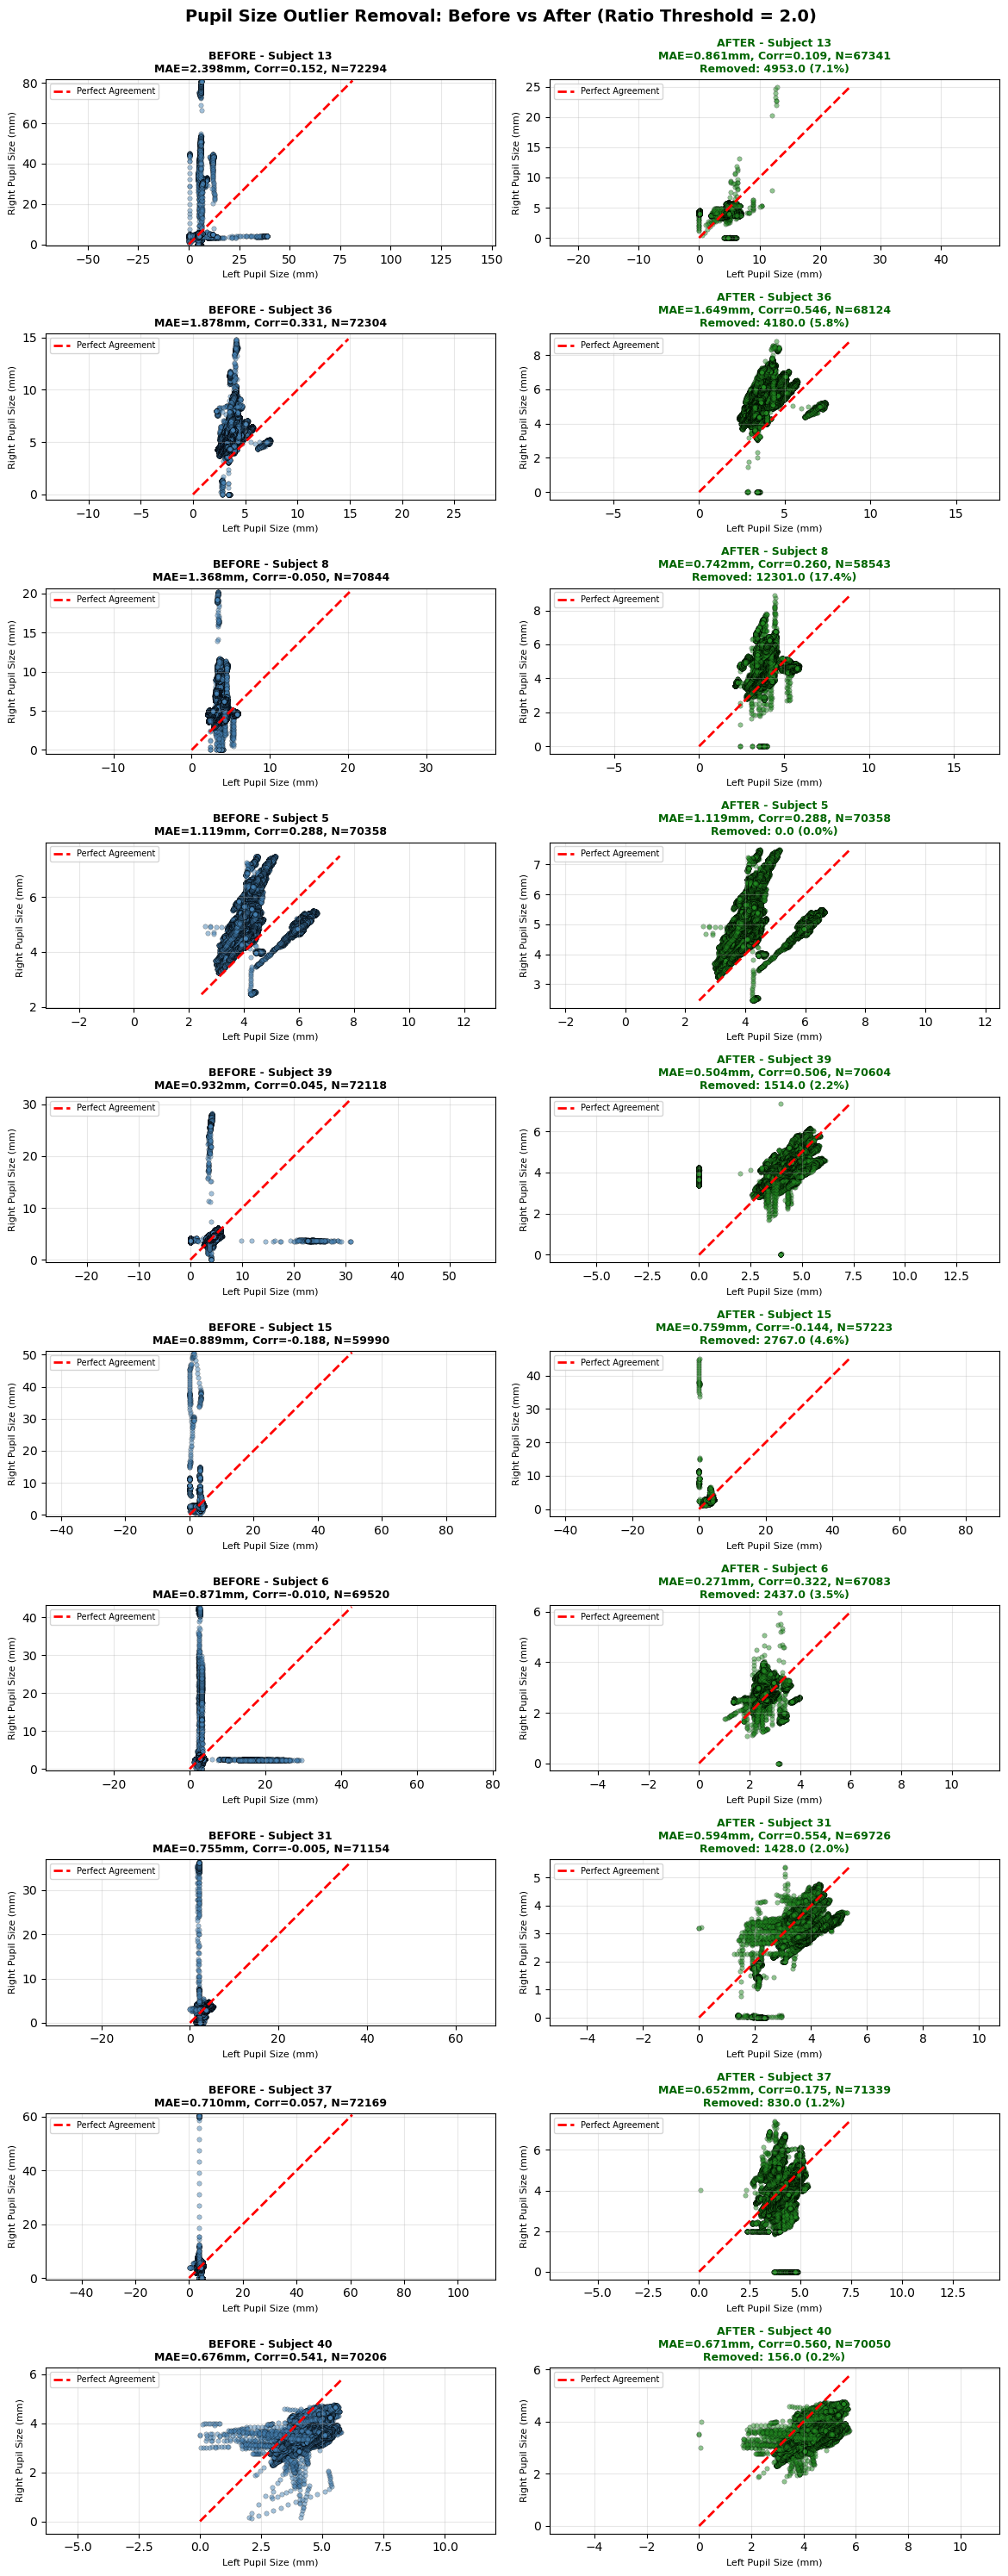

In [34]:
# Get the N most critical subjects from original data
N = 10
critical_subjects = stats_original.head(N)['subject'].values

# Create before/after comparison plots
fig, axes = plt.subplots(N, 2, figsize=(12, 3*N))

for idx, subject in enumerate(critical_subjects):
    # BEFORE (left column)
    df_subj_orig = df[df['subject'] == subject][['pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    left_orig = df_subj_orig['pupil-size-left-avg']
    right_orig = df_subj_orig['pupil-size-right-avg']
    
    ax_before = axes[idx, 0]
    ax_before.scatter(left_orig, right_orig, alpha=0.5, s=15, color='steelblue', edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    min_val_orig = min(left_orig.min(), right_orig.min())
    max_val_orig = max(left_orig.max(), right_orig.max())
    ax_before.plot([min_val_orig, max_val_orig], [min_val_orig, max_val_orig], 'r--', linewidth=2, label='Perfect Agreement')
    
    # Statistics
    stats_orig = stats_original[stats_original['subject'] == subject].iloc[0]
    ax_before.set_title(f"BEFORE - Subject {subject}\nMAE={stats_orig['mae']:.3f}mm, Corr={stats_orig['corr']:.3f}, N={len(left_orig)}", 
                       fontsize=9, fontweight='bold')
    ax_before.set_xlabel('Left Pupil Size (mm)', fontsize=8)
    ax_before.set_ylabel('Right Pupil Size (mm)', fontsize=8)
    ax_before.legend(loc='upper left', fontsize=7)
    ax_before.grid(alpha=0.3)
    ax_before.axis('equal')
    ax_before.set_xlim(min_val_orig - 0.5, max_val_orig + 0.5)
    ax_before.set_ylim(min_val_orig - 0.5, max_val_orig + 0.5)
    
    # AFTER (right column)
    df_subj_clean = df_cleaned[df_cleaned['subject'] == subject][['pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    left_clean = df_subj_clean['pupil-size-left-avg']
    right_clean = df_subj_clean['pupil-size-right-avg']
    
    ax_after = axes[idx, 1]
    ax_after.scatter(left_clean, right_clean, alpha=0.5, s=15, color='forestgreen', edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    if len(left_clean) > 0:
        min_val_clean = min(left_clean.min(), right_clean.min())
        max_val_clean = max(left_clean.max(), right_clean.max())
        ax_after.plot([min_val_clean, max_val_clean], [min_val_clean, max_val_clean], 'r--', linewidth=2, label='Perfect Agreement')
        
        # Statistics
        stats_clean = stats_cleaned[stats_cleaned['subject'] == subject].iloc[0]
        removal = removal_stats[removal_stats['subject'] == subject].iloc[0]
        ax_after.set_title(f"AFTER - Subject {subject}\nMAE={stats_clean['mae']:.3f}mm, Corr={stats_clean['corr']:.3f}, N={len(left_clean)}\nRemoved: {removal['outliers_removed']} ({removal['pct_removed']:.1f}%)", 
                          fontsize=9, fontweight='bold', color='darkgreen')
        ax_after.set_xlim(min_val_clean - 0.5, max_val_clean + 0.5)
        ax_after.set_ylim(min_val_clean - 0.5, max_val_clean + 0.5)
    else:
        ax_after.set_title(f"AFTER - Subject {subject}\nNo valid data remaining", 
                          fontsize=9, fontweight='bold', color='red')
    
    ax_after.set_xlabel('Left Pupil Size (mm)', fontsize=8)
    ax_after.set_ylabel('Right Pupil Size (mm)', fontsize=8)
    ax_after.legend(loc='upper left', fontsize=7)
    ax_after.grid(alpha=0.3)
    ax_after.axis('equal')

plt.suptitle(f'Pupil Size Outlier Removal: Before vs After (Ratio Threshold = {ratio_threshold})', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Overall Improvement Comparison

In [35]:
# Compare overall statistics
print("\n" + "="*80)
print("OVERALL IMPROVEMENT:")
print("="*80)
print(f"\nMedian MAE:")
print(f"  Before: {stats_original['mae'].median():.4f} mm")
print(f"  After:  {stats_cleaned['mae'].median():.4f} mm")
print(f"  Improvement: {((stats_original['mae'].median() - stats_cleaned['mae'].median()) / stats_original['mae'].median() * 100):.1f}%")

print(f"\nMedian Correlation:")
print(f"  Before: {stats_original['corr'].median():.4f}")
print(f"  After:  {stats_cleaned['corr'].median():.4f}")
print(f"  Improvement: {((stats_cleaned['corr'].median() - stats_original['corr'].median()) / (1 - stats_original['corr'].median()) * 100):.1f}%")

print(f"\nSubjects with MAE > 0.5 mm:")
print(f"  Before: {(stats_original['mae'] > 0.5).sum()}")
print(f"  After:  {(stats_cleaned['mae'] > 0.5).sum()}")

print(f"\nSubjects with correlation < 0.9:")
print(f"  Before: {(stats_original['corr'] < 0.9).sum()}")
print(f"  After:  {(stats_cleaned['corr'] < 0.9).sum()}")


OVERALL IMPROVEMENT:

Median MAE:
  Before: 0.3772 mm
  After:  0.3439 mm
  Improvement: 8.8%

Median Correlation:
  Before: 0.6001
  After:  0.6319
  Improvement: 7.9%

Subjects with MAE > 0.5 mm:
  Before: 15
  After:  12

Subjects with correlation < 0.9:
  Before: 44
  After:  44


## Distribution of MAE Before vs After

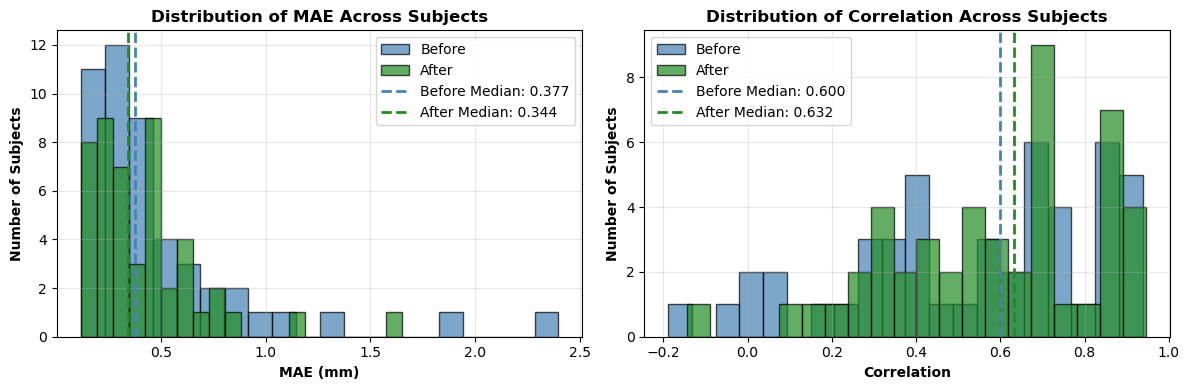

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE distribution
axes[0].hist(stats_original['mae'], bins=20, alpha=0.7, color='steelblue', label='Before', edgecolor='black')
axes[0].hist(stats_cleaned['mae'], bins=20, alpha=0.7, color='forestgreen', label='After', edgecolor='black')
axes[0].axvline(stats_original['mae'].median(), color='steelblue', linestyle='--', linewidth=2, label=f'Before Median: {stats_original["mae"].median():.3f}')
axes[0].axvline(stats_cleaned['mae'].median(), color='forestgreen', linestyle='--', linewidth=2, label=f'After Median: {stats_cleaned["mae"].median():.3f}')
axes[0].set_xlabel('MAE (mm)', fontweight='bold')
axes[0].set_ylabel('Number of Subjects', fontweight='bold')
axes[0].set_title('Distribution of MAE Across Subjects', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Correlation distribution
axes[1].hist(stats_original['corr'], bins=20, alpha=0.7, color='steelblue', label='Before', edgecolor='black')
axes[1].hist(stats_cleaned['corr'], bins=20, alpha=0.7, color='forestgreen', label='After', edgecolor='black')
axes[1].axvline(stats_original['corr'].median(), color='steelblue', linestyle='--', linewidth=2, label=f'Before Median: {stats_original["corr"].median():.3f}')
axes[1].axvline(stats_cleaned['corr'].median(), color='forestgreen', linestyle='--', linewidth=2, label=f'After Median: {stats_cleaned["corr"].median():.3f}')
axes[1].set_xlabel('Correlation', fontweight='bold')
axes[1].set_ylabel('Number of Subjects', fontweight='bold')
axes[1].set_title('Distribution of Correlation Across Subjects', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Next Steps

The cleaned data is in `df_cleaned`. When ready to save:
1. Decide on output directory (e.g., `../../data/processed/eSEEd_v2_cleaned/`)
2. Save per-subject files maintaining the same structure
3. Update preprocessing pipeline to use cleaned data

In [ ]:
# Preview cleaned data
print("Cleaned data preview:")
print(df_cleaned.head())
print(f"\nShape: {df_cleaned.shape}")
print(f"Pupil columns null counts:")
print(df_cleaned[['pupil-size-left-avg', 'pupil-size-right-avg']].isnull().sum())

Cleaned data preview:
   time-rel-seconds     x-avg     y-avg  confidence-gaze-left  \
0              0.00  0.471631  0.700136              0.999430   
1              0.01  0.472548  0.698492              0.999390   
2              0.02  0.472042  0.699332              0.999703   
3              0.03  0.471360  0.700148              0.999672   
4              0.04  0.471762  0.698082              0.999512   

   confidence-gaze-right  pupil-size-left-avg  pupil-size-right-avg  subject  \
0               0.999430             2.692518              2.934442       14   
1               0.999390             2.684385              2.937808       14   
2               0.999703             2.683800              2.949406       14   
3               0.999672             2.687721              2.956630       14   
4               0.999512             2.695726              2.968258       14   

   recording  emotion-anger  emotion-tenderness  emotion-sadness  \
0          7            0.0           

### Visualize Best Strategy on Critical Subjects

Show before/after for the recommended strategy.

## Strategy Comparison: Expert Approaches

Compare multiple outlier removal strategies to find the optimal approach.

In [38]:
def apply_cleaning_strategy(df, strategy_name, criterion_fn):
    """
    Apply a cleaning strategy and return cleaned df + stats.
    
    Args:
        df: Original DataFrame
        strategy_name: Name of the strategy
        criterion_fn: Function that takes (left, right) arrays and returns outlier mask
        
    Returns:
        df_clean, removal_stats, improvement_stats
    """
    df_clean = df.copy()
    
    left = df_clean['pupil-size-left-avg'].values
    right = df_clean['pupil-size-right-avg'].values
    
    # Find valid points
    min_valid_size = 0.1
    valid_mask = (left > min_valid_size) & (right > min_valid_size) & (~np.isnan(left)) & (~np.isnan(right))
    
    # Apply criterion to valid points
    outlier_mask = np.zeros(len(df_clean), dtype=bool)
    if valid_mask.any():
        outlier_mask[valid_mask] = criterion_fn(left[valid_mask], right[valid_mask])
    
    # Remove outliers
    df_clean.loc[outlier_mask, 'pupil-size-left-avg'] = np.nan
    df_clean.loc[outlier_mask, 'pupil-size-right-avg'] = np.nan
    
    # Compute statistics per subject
    stats = []
    for subject in df['subject'].unique():
        subject_mask = df['subject'] == subject
        initial_valid = valid_mask[subject_mask].sum()
        outliers_in_subject = outlier_mask[subject_mask].sum()
        
        if initial_valid > 0:
            pct_removed = (outliers_in_subject / initial_valid) * 100
        else:
            pct_removed = 0
        
        stats.append({
            'subject': subject,
            'initial_valid': int(initial_valid),
            'outliers_removed': int(outliers_in_subject),
            'pct_removed': pct_removed,
            'remaining_valid': int(initial_valid - outliers_in_subject)
        })
    
    df_stats = pd.DataFrame(stats)
    
    # Compute improvement metrics
    stats_before = compute_pupil_stats(df)
    stats_after = compute_pupil_stats(df_clean)
    
    improvement = {
        'strategy': strategy_name,
        'total_points_removed': int(outlier_mask.sum()),
        'pct_data_loss': (outlier_mask.sum() / valid_mask.sum()) * 100,
        'median_mae_before': stats_before['mae'].median(),
        'median_mae_after': stats_after['mae'].median(),
        'mae_improvement_pct': ((stats_before['mae'].median() - stats_after['mae'].median()) / stats_before['mae'].median()) * 100,
        'median_corr_before': stats_before['corr'].median(),
        'median_corr_after': stats_after['corr'].median(),
        'subjects_mae_gt_0.5_before': (stats_before['mae'] > 0.5).sum(),
        'subjects_mae_gt_0.5_after': (stats_after['mae'] > 0.5).sum(),
    }
    
    return df_clean, df_stats, improvement

print("Strategy comparison functions defined.")

Strategy comparison functions defined.


In [42]:
# Define multiple cleaning strategies
strategies = {
    'ratio_2.0x': lambda l, r: np.maximum(l/r, r/l) > 2.0,
    'ratio_3.0x': lambda l, r: np.maximum(l/r, r/l) > 3.0,
    'abs_1.0mm': lambda l, r: np.abs(l - r) > 1.0,
    'abs_1.5mm': lambda l, r: np.abs(l - r) > 1.5,
    'abs_2.0mm': lambda l, r: np.abs(l - r) > 2.0,
    'hybrid_abs1.5_ratio2': lambda l, r: (np.abs(l - r) > 1.5) | (np.maximum(l/r, r/l) > 2.0),
    'hybrid_abs2_ratio2': lambda l, r: (np.abs(l - r) > 2.0) | (np.maximum(l/r, r/l) > 2.0),
    'hybrid_abs2_ratio3': lambda l, r: (np.abs(l - r) > 2.0) | (np.maximum(l/r, r/l) > 3.0),
}

# Apply each strategy and collect results
print("Testing strategies...")
results = []
cleaned_dfs = {}

for name, criterion in strategies.items():
    print(f"  Testing: {name}...")
    df_clean, removal_stats, improvement = apply_cleaning_strategy(df, name, criterion)
    results.append(improvement)
    cleaned_dfs[name] = df_clean

# Create comparison DataFrame
df_comparison = pd.DataFrame(results)
df_comparison = df_comparison.sort_values('mae_improvement_pct', ascending=False)

print("\n" + "="*100)
print("STRATEGY COMPARISON RESULTS")
print("="*100)
print(df_comparison.to_string(index=False))

# Highlight best strategies
print("\n" + "="*100)
print("RECOMMENDATIONS:")
print("="*100)
print(f"\nBest MAE improvement: {df_comparison.iloc[0]['strategy']} ({df_comparison.iloc[0]['mae_improvement_pct']:.1f}% improvement)")
print(f"  → Removes {df_comparison.iloc[0]['pct_data_loss']:.2f}% of data")
print(f"  → MAE: {df_comparison.iloc[0]['median_mae_before']:.4f} → {df_comparison.iloc[0]['median_mae_after']:.4f} mm")

# Find best balance (good improvement, low data loss)
df_comparison['score'] = df_comparison['mae_improvement_pct'] / (df_comparison['pct_data_loss'] + 0.1)  # Avoid div by 0
# best_balance_idx = df_comparison['score'].idxmax()
best_balance_idx = df_comparison['score'].idxmin()
print(f"\nBest balance (improvement/data_loss): {df_comparison.loc[best_balance_idx, 'strategy']}")
print(f"  → Removes {df_comparison.loc[best_balance_idx, 'pct_data_loss']:.2f}% of data")
print(f"  → MAE improvement: {df_comparison.loc[best_balance_idx, 'mae_improvement_pct']:.1f}%")

Testing strategies...
  Testing: ratio_2.0x...
  Testing: ratio_3.0x...
  Testing: abs_1.0mm...
  Testing: abs_1.5mm...
  Testing: abs_2.0mm...
  Testing: hybrid_abs1.5_ratio2...
  Testing: hybrid_abs2_ratio2...
  Testing: hybrid_abs2_ratio3...

STRATEGY COMPARISON RESULTS
            strategy  total_points_removed  pct_data_loss  median_mae_before  median_mae_after  mae_improvement_pct  median_corr_before  median_corr_after  subjects_mae_gt_0.5_before  subjects_mae_gt_0.5_after
           abs_1.0mm                321581       9.544040           0.377236          0.322089            14.618783            0.600113           0.722683                          15                          5
hybrid_abs1.5_ratio2                132033       3.918541           0.377236          0.339527             9.996204            0.600113           0.671603                          15                         12
           abs_1.5mm                130993       3.887675           0.377236          0.339577  

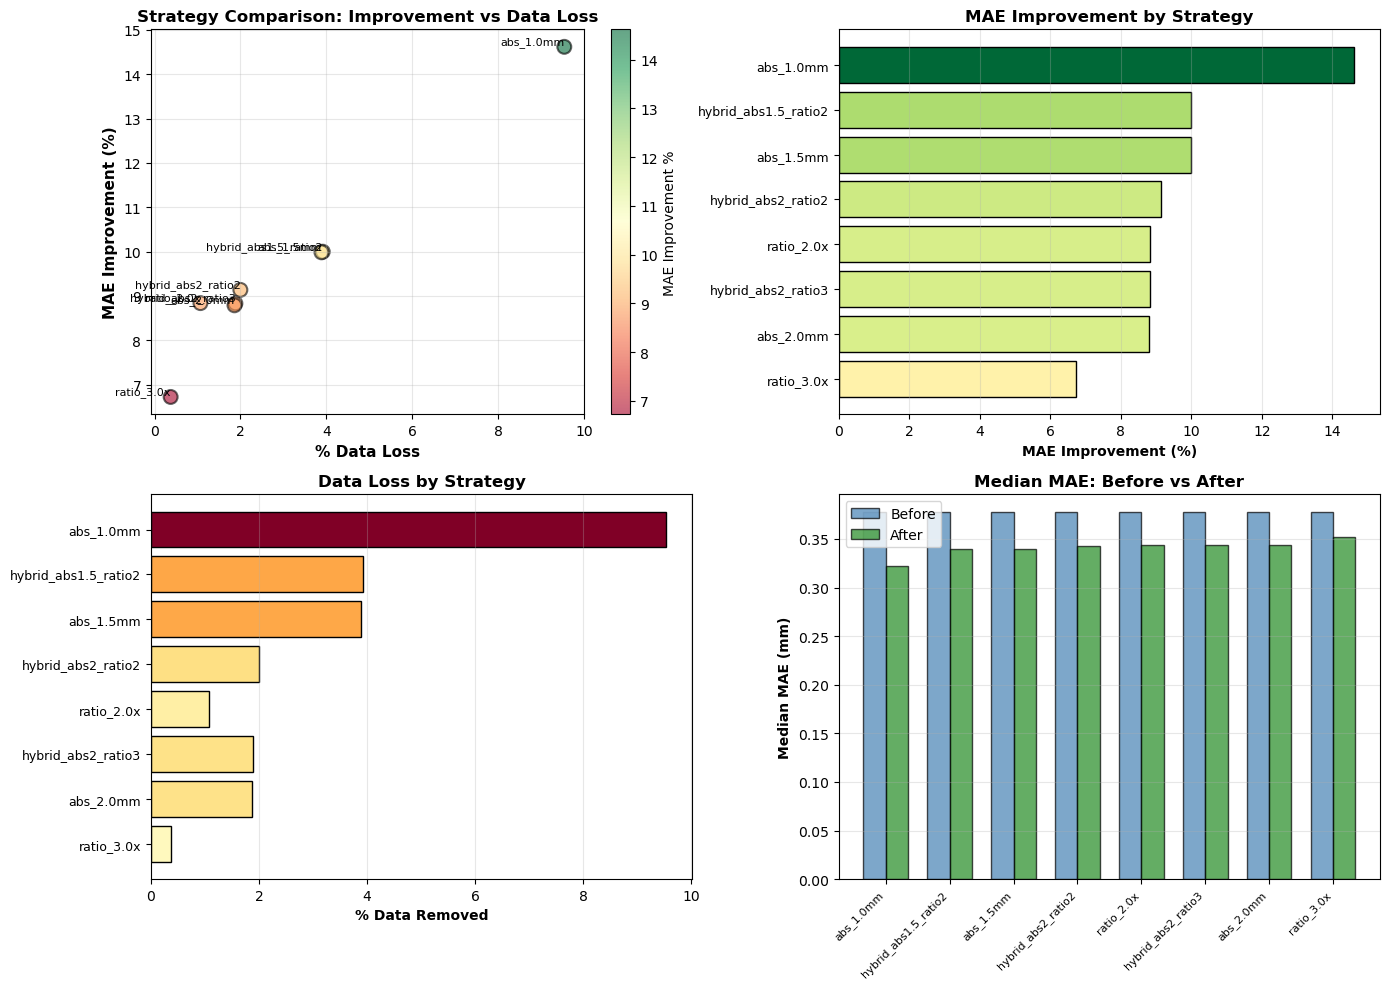

In [43]:
# Visualize strategy comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE improvement vs Data loss (scatter)
ax = axes[0, 0]
scatter = ax.scatter(df_comparison['pct_data_loss'], 
                    df_comparison['mae_improvement_pct'],
                    s=100, alpha=0.6, c=df_comparison['mae_improvement_pct'], 
                    cmap='RdYlGn', edgecolors='black', linewidth=1.5)
for idx, row in df_comparison.iterrows():
    ax.annotate(row['strategy'], 
               (row['pct_data_loss'], row['mae_improvement_pct']),
               fontsize=8, ha='right', va='bottom')
ax.set_xlabel('% Data Loss', fontweight='bold', fontsize=11)
ax.set_ylabel('MAE Improvement (%)', fontweight='bold', fontsize=11)
ax.set_title('Strategy Comparison: Improvement vs Data Loss', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='MAE Improvement %')

# Plot 2: Bar chart of MAE improvement
ax = axes[0, 1]
bars = ax.barh(range(len(df_comparison)), df_comparison['mae_improvement_pct'], 
               color=plt.cm.RdYlGn(df_comparison['mae_improvement_pct'] / df_comparison['mae_improvement_pct'].max()),
               edgecolor='black', linewidth=1)
ax.set_yticks(range(len(df_comparison)))
ax.set_yticklabels(df_comparison['strategy'], fontsize=9)
ax.set_xlabel('MAE Improvement (%)', fontweight='bold')
ax.set_title('MAE Improvement by Strategy', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Plot 3: Data loss comparison
ax = axes[1, 0]
bars = ax.barh(range(len(df_comparison)), df_comparison['pct_data_loss'],
               color=plt.cm.YlOrRd(df_comparison['pct_data_loss'] / df_comparison['pct_data_loss'].max()),
               edgecolor='black', linewidth=1)
ax.set_yticks(range(len(df_comparison)))
ax.set_yticklabels(df_comparison['strategy'], fontsize=9)
ax.set_xlabel('% Data Removed', fontweight='bold')
ax.set_title('Data Loss by Strategy', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Plot 4: Before/After MAE comparison
ax = axes[1, 1]
x = np.arange(len(df_comparison))
width = 0.35
bars1 = ax.bar(x - width/2, df_comparison['median_mae_before'], width, 
              label='Before', alpha=0.7, color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, df_comparison['median_mae_after'], width,
              label='After', alpha=0.7, color='forestgreen', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['strategy'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median MAE (mm)', fontweight='bold')
ax.set_title('Median MAE: Before vs After', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing: abs_1.0mm
  MAE improvement: 14.6%
  Data loss: 9.54%


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


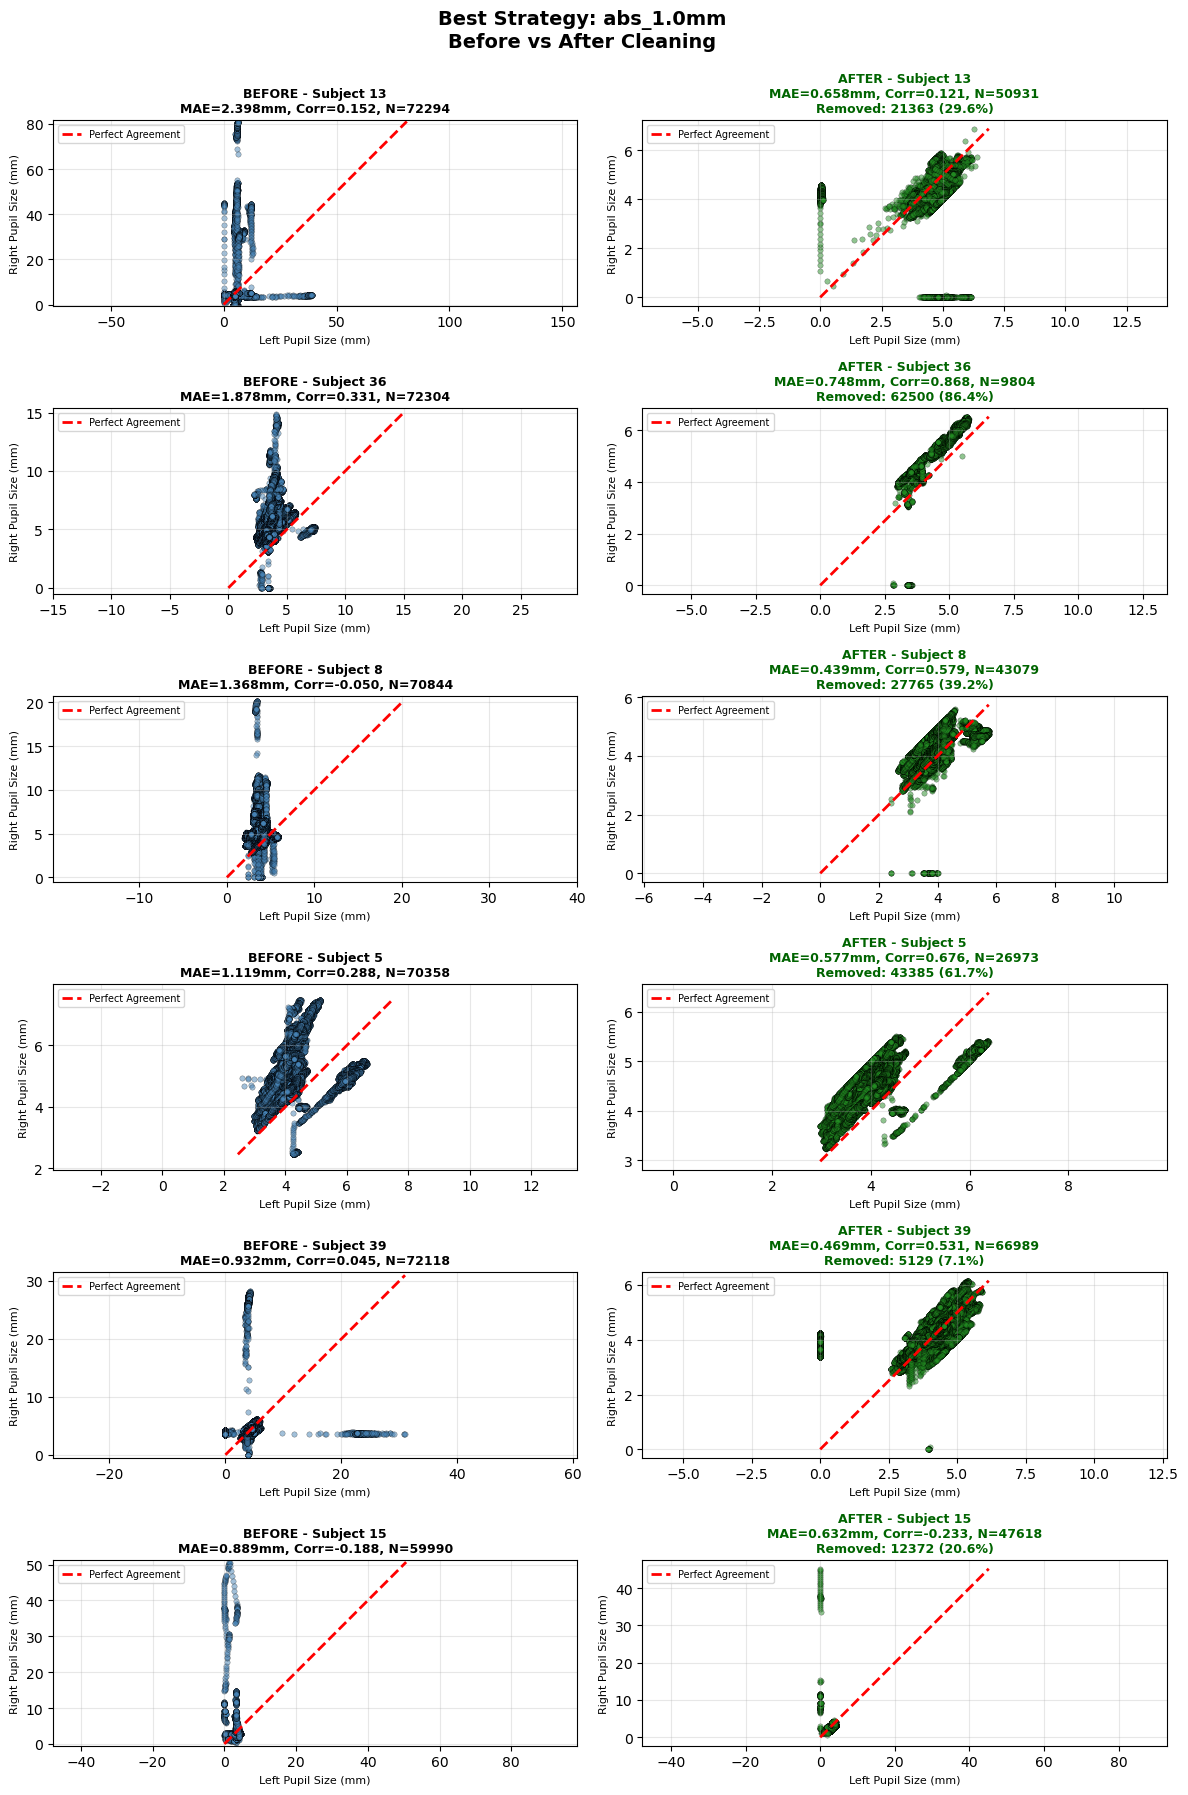


FINAL RECOMMENDATION:

Use strategy: abs_1.0mm
  Rationale: Best balance between data quality improvement and minimal data loss
  MAE improvement: 14.6%
  Data loss: 9.54%
  Median MAE: 0.3772 → 0.3221 mm
  Subjects with MAE > 0.5mm: 15 → 5

The cleaned data is available in: cleaned_dfs['abs_1.0mm']


In [44]:
# Use the best strategy based on balance score
best_strategy_name = df_comparison.loc[best_balance_idx, 'strategy']
df_best_cleaned = cleaned_dfs[best_strategy_name]

print(f"Visualizing: {best_strategy_name}")
print(f"  MAE improvement: {df_comparison.loc[best_balance_idx, 'mae_improvement_pct']:.1f}%")
print(f"  Data loss: {df_comparison.loc[best_balance_idx, 'pct_data_loss']:.2f}%")

# Compute stats for visualization
stats_original_best = compute_pupil_stats(df, "original")
stats_cleaned_best = compute_pupil_stats(df_best_cleaned, "cleaned")

# Get critical subjects
N = 6
critical_subjects_best = stats_original_best.head(N)['subject'].values

# Create before/after comparison plots
fig, axes = plt.subplots(N, 2, figsize=(12, 3*N))

for idx, subject in enumerate(critical_subjects_best):
    # BEFORE (left column)
    df_subj_orig = df[df['subject'] == subject][['pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    left_orig = df_subj_orig['pupil-size-left-avg']
    right_orig = df_subj_orig['pupil-size-right-avg']
    
    ax_before = axes[idx, 0]
    ax_before.scatter(left_orig, right_orig, alpha=0.5, s=15, color='steelblue', edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    min_val_orig = min(left_orig.min(), right_orig.min())
    max_val_orig = max(left_orig.max(), right_orig.max())
    ax_before.plot([min_val_orig, max_val_orig], [min_val_orig, max_val_orig], 'r--', linewidth=2, label='Perfect Agreement')
    
    # Statistics
    stats_orig = stats_original_best[stats_original_best['subject'] == subject].iloc[0]
    ax_before.set_title(f"BEFORE - Subject {subject}\nMAE={stats_orig['mae']:.3f}mm, Corr={stats_orig['corr']:.3f}, N={len(left_orig)}", 
                       fontsize=9, fontweight='bold')
    ax_before.set_xlabel('Left Pupil Size (mm)', fontsize=8)
    ax_before.set_ylabel('Right Pupil Size (mm)', fontsize=8)
    ax_before.legend(loc='upper left', fontsize=7)
    ax_before.grid(alpha=0.3)
    ax_before.axis('equal')
    ax_before.set_xlim(min_val_orig - 0.5, max_val_orig + 0.5)
    ax_before.set_ylim(min_val_orig - 0.5, max_val_orig + 0.5)
    
    # AFTER (right column)
    df_subj_clean = df_best_cleaned[df_best_cleaned['subject'] == subject][['pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    left_clean = df_subj_clean['pupil-size-left-avg']
    right_clean = df_subj_clean['pupil-size-right-avg']
    
    ax_after = axes[idx, 1]
    ax_after.scatter(left_clean, right_clean, alpha=0.5, s=15, color='forestgreen', edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    if len(left_clean) > 0:
        min_val_clean = min(left_clean.min(), right_clean.min())
        max_val_clean = max(left_clean.max(), right_clean.max())
        ax_after.plot([min_val_clean, max_val_clean], [min_val_clean, max_val_clean], 'r--', linewidth=2, label='Perfect Agreement')
        
        # Statistics
        stats_clean = stats_cleaned_best[stats_cleaned_best['subject'] == subject].iloc[0]
        n_removed = len(left_orig) - len(left_clean)
        pct_removed = (n_removed / len(left_orig)) * 100 if len(left_orig) > 0 else 0
        ax_after.set_title(f"AFTER - Subject {subject}\nMAE={stats_clean['mae']:.3f}mm, Corr={stats_clean['corr']:.3f}, N={len(left_clean)}\nRemoved: {n_removed} ({pct_removed:.1f}%)", 
                          fontsize=9, fontweight='bold', color='darkgreen')
        ax_after.set_xlim(min_val_clean - 0.5, max_val_clean + 0.5)
        ax_after.set_ylim(min_val_clean - 0.5, max_val_clean + 0.5)
    else:
        ax_after.set_title(f"AFTER - Subject {subject}\nNo valid data remaining", 
                          fontsize=9, fontweight='bold', color='red')
    
    ax_after.set_xlabel('Left Pupil Size (mm)', fontsize=8)
    ax_after.set_ylabel('Right Pupil Size (mm)', fontsize=8)
    ax_after.legend(loc='upper left', fontsize=7)
    ax_after.grid(alpha=0.3)
    ax_after.axis('equal')

plt.suptitle(f'Best Strategy: {best_strategy_name}\nBefore vs After Cleaning', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print final recommendation
print("\n" + "="*100)
print("FINAL RECOMMENDATION:")
print("="*100)
print(f"\nUse strategy: {best_strategy_name}")
print(f"  Rationale: Best balance between data quality improvement and minimal data loss")
print(f"  MAE improvement: {df_comparison.loc[best_balance_idx, 'mae_improvement_pct']:.1f}%")
print(f"  Data loss: {df_comparison.loc[best_balance_idx, 'pct_data_loss']:.2f}%")
print(f"  Median MAE: {df_comparison.loc[best_balance_idx, 'median_mae_before']:.4f} → {df_comparison.loc[best_balance_idx, 'median_mae_after']:.4f} mm")
print(f"  Subjects with MAE > 0.5mm: {int(df_comparison.loc[best_balance_idx, 'subjects_mae_gt_0.5_before'])} → {int(df_comparison.loc[best_balance_idx, 'subjects_mae_gt_0.5_after'])}")
print(f"\nThe cleaned data is available in: cleaned_dfs['{best_strategy_name}']")